In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from joblib import dump

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import AdaBoostClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report

In [2]:
df = pd.read_csv("rainfall.csv")
df.head()

,datetime,temp,dew,humidity,sealevelpressure,winddir,solarradiation,windspeed,precipprob,preciptype
0,01-01-2016,28.4,11.9,37.8,1016.4,147.5,216.1,16.6,0,0
1,02-01-2016,26.8,13.0,44.8,1017.2,110.3,215.7,16.6,0,0
2,03-01-2016,25.5,14.6,52.8,1015.7,145.3,221.1,18.4,0,0
3,04-01-2016,26.4,13.1,46.6,1015.3,126.9,216.2,16.6,0,0
4,05-01-2016,27.1,13.5,44.9,1014.4,125.5,208.1,16.6,0,0


In [3]:
df.columns

Index(['datetime', 'temp', 'dew', 'humidity', 'sealevelpressure', 'winddir',
       'solarradiation', 'windspeed', 'precipprob', 'preciptype'],
      dtype='object')

In [4]:
df.shape

(1781, 10)

In [5]:
df = df.drop("datetime",axis=1)
df.head()

,temp,dew,humidity,sealevelpressure,winddir,solarradiation,windspeed,precipprob,preciptype
0,28.4,11.9,37.8,1016.4,147.5,216.1,16.6,0,0
1,26.8,13.0,44.8,1017.2,110.3,215.7,16.6,0,0
2,25.5,14.6,52.8,1015.7,145.3,221.1,18.4,0,0
3,26.4,13.1,46.6,1015.3,126.9,216.2,16.6,0,0
4,27.1,13.5,44.9,1014.4,125.5,208.1,16.6,0,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1781 entries, 0 to 1780
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   temp              1781 non-null   float64
 1   dew               1781 non-null   float64
 2   humidity          1781 non-null   float64
 3   sealevelpressure  1781 non-null   float64
 4   winddir           1781 non-null   float64
 5   solarradiation    1781 non-null   float64
 6   windspeed         1781 non-null   float64
 7   precipprob        1781 non-null   int64  
 8   preciptype        1781 non-null   int64  
dtypes: float64(7), int64(2)
memory usage: 125.4 KB


In [7]:
df.describe()

,temp,dew,humidity,sealevelpressure,winddir,solarradiation,windspeed,precipprob,preciptype
count,1781.000000,1781.000000,1781.000000,1781.000000,1781.000000,1781.000000,1781.000000,1781.000000,1781.000000
mean,28.342560,21.644975,69.565974,1008.878046,201.304267,228.169175,22.309882,45.648512,0.456485
std,1.960027,4.532065,14.533809,3.706157,47.075559,57.034865,6.360669,49.824275,0.498243
min,20.200000,5.000000,28.600000,994.100000,65.600000,52.800000,9.400000,0.000000,0.000000
25%,27.200000,18.100000,58.000000,1006.200000,163.700000,194.600000,18.400000,0.000000,0.000000
50%,28.500000,23.800000,71.600000,1009.100000,204.500000,232.300000,22.300000,0.000000,0.000000
75%,29.700000,25.300000,81.200000,1011.800000,240.900000,274.400000,24.600000,100.000000,1.000000
max,32.800000,27.500000,98.200000,1017.400000,316.000000,330.900000,128.100000,100.000000,1.000000


In [8]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [9]:
df.isnull().sum()

temp                0
dew                 0
humidity            0
sealevelpressure    0
winddir             0
solarradiation      0
windspeed           0
precipprob          0
preciptype          0
dtype: int64

In [10]:
df["precipprob"].unique().sum()

np.int64(100)

In [11]:
df.head()

,temp,dew,humidity,sealevelpressure,winddir,solarradiation,windspeed,precipprob,preciptype
0,28.4,11.9,37.8,1016.4,147.5,216.1,16.6,0,0
1,26.8,13.0,44.8,1017.2,110.3,215.7,16.6,0,0
2,25.5,14.6,52.8,1015.7,145.3,221.1,18.4,0,0
3,26.4,13.1,46.6,1015.3,126.9,216.2,16.6,0,0
4,27.1,13.5,44.9,1014.4,125.5,208.1,16.6,0,0


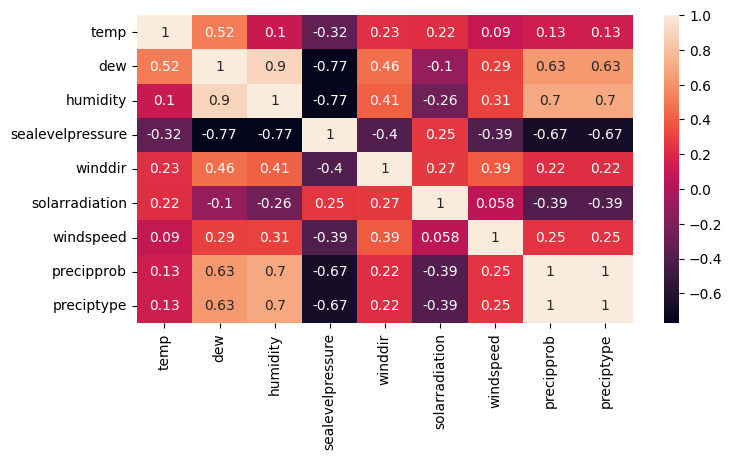

In [12]:
plt.figure(figsize=(8,4))
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

In [13]:
columns = ['temp', 'dew', 'humidity', 'sealevelpressure', 'winddir','solarradiation', 'windspeed']
scaler = StandardScaler()

df[columns] = scaler.fit_transform(df[columns])
df.head()

,temp,dew,humidity,sealevelpressure,winddir,solarradiation,windspeed,precipprob,preciptype
0,0.029314,-2.150832,-2.186274,2.030153,-1.143255,-0.211670,-0.897938,0,0
1,-0.787231,-1.908049,-1.704504,2.246071,-1.933696,-0.218685,-0.897938,0,0
2,-1.450674,-1.554910,-1.153908,1.841225,-1.190002,-0.123980,-0.614869,0,0
3,-0.991367,-1.885978,-1.580620,1.733266,-1.580973,-0.209916,-0.897938,0,0
4,-0.634129,-1.797693,-1.697621,1.490359,-1.610720,-0.351974,-0.897938,0,0


In [14]:
X = df[['temp', 'dew', 'humidity', 'sealevelpressure', 'winddir',
'solarradiation', 'windspeed']]
y = df['preciptype']
X.head()

,temp,dew,humidity,sealevelpressure,winddir,solarradiation,windspeed
0,0.029314,-2.150832,-2.186274,2.030153,-1.143255,-0.211670,-0.897938
1,-0.787231,-1.908049,-1.704504,2.246071,-1.933696,-0.218685,-0.897938
2,-1.450674,-1.554910,-1.153908,1.841225,-1.190002,-0.123980,-0.614869
3,-0.991367,-1.885978,-1.580620,1.733266,-1.580973,-0.209916,-0.897938
4,-0.634129,-1.797693,-1.697621,1.490359,-1.610720,-0.351974,-0.897938


In [15]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: preciptype, dtype: int64

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [17]:
lo_model = LogisticRegression()

lo_model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [18]:
y_pred = lo_model.predict(X_test)
accuracy_score(y_pred,y_test)

0.9215686274509803

In [19]:
dump(lo_model,"model.pkl")
dump(scaler,"scaler.pkl")
dump(X.columns.tolist(),"columns.pkl")

['columns.pkl']